In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from medmnist import ChestMNIST
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, f1_score

In [2]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

train_dataset = ChestMNIST(split='train', download=True, size=64, transform=transform)
val_dataset   = ChestMNIST(split='val',   download=True, size=64, transform=transform)
test_dataset  = ChestMNIST(split='test',  download=True, size=64, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

label_names = list(train_dataset.info['label'].values())

print("Data chargée")

Data chargée


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")

# Charger ResNet18 pré-entraîné
model = models.resnet18(pretrained=True)

# ResNet attend 3 canaux, on adapte la première couche pour 1 canal (grayscale)
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

# Remplacer la dernière couche pour 14 classes
model.fc = nn.Linear(model.fc.in_features, 14)

model = model.to(device)
print("ResNet18 chargé ")

Device : cpu
ResNet18 chargé 


In [6]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

torch.manual_seed(42)
np.random.seed(42)

print("Setup ok ")

Setup ok 


In [7]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=3):
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        # ── Train ──
        model.train()
        running_loss = 0
        for imgs, labels in train_loader:
            imgs = imgs.to(device)
            labels = labels.float().to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)

        # ── Validation ──
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs = imgs.to(device)
                labels = labels.float().to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

        val_loss = val_loss / len(val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    return train_losses, val_losses

train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=3)

Epoch [1/3] | Train Loss: 0.1769 | Val Loss: 0.1704
Epoch [2/3] | Train Loss: 0.1702 | Val Loss: 0.1748
Epoch [3/3] | Train Loss: 0.1674 | Val Loss: 0.1688


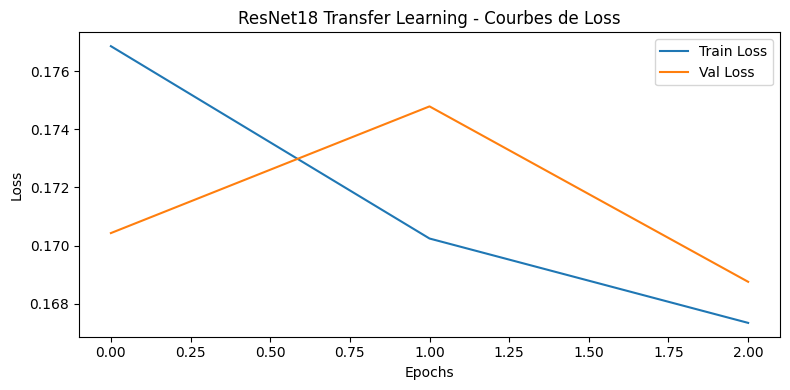

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('ResNet18 Transfer Learning - Courbes de Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = torch.sigmoid(model(imgs))
        all_preds.append(outputs.cpu().numpy())
        all_labels.append(labels.numpy())

all_preds = np.concatenate(all_preds, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

all_preds_binary = (all_preds >= 0.5).astype(int)

aucs = []
print("=" * 45)
print(f"{'Pathologie':<20} | {'AUC':>6} | {'F1':>6}")
print("=" * 45)
for i, name in enumerate(label_names):
    auc = roc_auc_score(all_labels[:, i], all_preds[:, i])
    f1 = f1_score(all_labels[:, i], all_preds_binary[:, i], zero_division=0)
    aucs.append(auc)
    print(f"{name:<20} | {auc:>6.4f} | {f1:>6.4f}")

print("=" * 45)
print(f"{'Moyenne':<20} | {np.mean(aucs):>6.4f} | {f1_score(all_labels, all_preds_binary, average='macro', zero_division=0):>6.4f}")

torch.save(model.state_dict(), 'cnn_transfer.pth')
print("\nModèle sauvegardé ")

Pathologie           |    AUC |     F1
atelectasis          | 0.7409 | 0.0255
cardiomegaly         | 0.8140 | 0.1315
effusion             | 0.8033 | 0.2987
infiltration         | 0.6556 | 0.0081
mass                 | 0.6876 | 0.0000
nodule               | 0.6253 | 0.0000
pneumonia            | 0.6851 | 0.0000
pneumothorax         | 0.7469 | 0.0000
consolidation        | 0.7491 | 0.0000
edema                | 0.8387 | 0.0000
emphysema            | 0.7166 | 0.0000
fibrosis             | 0.7008 | 0.0000
pleural              | 0.6735 | 0.0000
hernia               | 0.7533 | 0.0000
Moyenne              | 0.7279 | 0.0331

Modèle sauvegardé 
